# Homework: Week 4
## Task 4.1: Loading the data & prepearing it

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("htru2/htru_2.csv", header=None)
df.head(5)

,0,1,2,3,4,5,6,7,8
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [3]:
df.shape

(17898, 9)

In [4]:
df.iloc[:, -1].value_counts()

8
0    16259
1     1639
Name: count, dtype: int64

In [5]:
column_names = [
    "Mean_Integrated_Profile",
    "Std_Integrated_Profile",
    "Excess_Kurtosis_Integrated_Profile",
    "Skewness_Integrated_Profile",
    "Mean_DMSNR_Curve",
    "Std_DMSNR_Curve",
    "Excess_Kurtosis_DMSNR_Curve",
    "Skewness_DMSNR_Curve",
    "Class"
]
df.columns = column_names

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Mean_Integrated_Profile             17898 non-null  float64
 1   Std_Integrated_Profile              17898 non-null  float64
 2   Excess_Kurtosis_Integrated_Profile  17898 non-null  float64
 3   Skewness_Integrated_Profile         17898 non-null  float64
 4   Mean_DMSNR_Curve                    17898 non-null  float64
 5   Std_DMSNR_Curve                     17898 non-null  float64
 6   Excess_Kurtosis_DMSNR_Curve         17898 non-null  float64
 7   Skewness_DMSNR_Curve                17898 non-null  float64
 8   Class                               17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [7]:
df.iloc[:, -1].value_counts()

Class
0    16259
1     1639
Name: count, dtype: int64

In [8]:
X = df.iloc[:, :-1].to_numpy()
Y = df.iloc[:, -1].replace({0: -1, 1: 1}).to_numpy()

print(X.shape)
print(Y.shape)

(17898, 8)
(17898,)


In [9]:
# Split the training data into training and validation sets

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, 
                                                    Y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    shuffle=True)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

print(np.unique(Y_train, return_counts=True))
print(np.unique(Y_test, return_counts=True))

(14318, 8)
(3580, 8)
(14318,)
(3580,)
(array([-1,  1]), array([13000,  1318]))
(array([-1,  1]), array([3259,  321]))


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
print(X_train.mean(axis=0))
print(X_train.std(axis=0))

[-2.13584951e-17  1.47249164e-17  9.03345316e-18 -2.60807036e-17
 -1.36471052e-18 -2.92404737e-17  2.00364317e-17 -1.02973612e-17]
[1. 1. 1. 1. 1. 1. 1. 1.]


## Task 4.2: "Real Task" - Implement Mini-batch SGD

In [14]:
class LinearBinaryClassification:
    """
    Linear binary classification class.

    Stores a linear classification model with parameters (w,b)
    and decision function h(x) = sign(w @ x + b)

    Parameters:
    ----------
    w: array
    b: array

    """
    def __init__(self, w, b):
        self.w = w
        self.b = b

    def decision_function(self, x):
        return x @ self.w + self.b
    
    def __call__(self, x):
        # Numpy's `where` function provides a fast substitution
        return np.where(self.decision_function(x) >= 0.0, 1, -1)
    
class GDClassifier(LinearBinaryClassification):
    """
    Gradient descent binary classifier
    """

    def loss(self, X, Y):
        """Loss function"""
        residual = self.decision_function(X) - Y
        return 0.5*np.mean(residual**2, axis=0)
    
    def loss_grad(self, X,Y):
        """Loss gradient"""
        residual = self.decision_function(X) - Y
        w_grad = X.T@residual/X.shape[0]
        b_grad = np.mean(residual, axis=0)
        return w_grad, b_grad
    
    
    def update(self, X, Y, lr = 1e-3):
        """Single step of GD"""
        grad_w, grad_b = self.loss_grad(X,Y)
        self.w -= lr*grad_w
        self.b -= lr*grad_b
               
    def fit(self, X, Y, lr = 1e-3, num_iter = 100):
        """GD training loop with num_iter epochs"""
        for _ in range(num_iter):
            self.update(X, Y, lr)
            
        return self.w, self.b

In [15]:
class SGDClassifier(LinearBinaryClassification):
    
    def loss(self, X, Y):
        residual = self.decision_function(X) - Y
        return 0.5 * np.mean(residual**2)
    
    def loss_grad(self, X, Y):
        residual = self.decision_function(X) - Y
        
        w_grad = X.T @ residual / X.shape[0]
        b_grad = np.mean(residual)
        
        return w_grad, b_grad
    
    def update(self, X_batch, Y_batch, lr=1e-3):
        w_grad, b_grad = self.loss_grad(X_batch, Y_batch)
        self.w -= lr * w_grad
        self.b -= lr * b_grad
    
    def fit(self, X, Y, lr=1e-3, num_epochs=10, batch_size=32):
        losses = []
        accuracies = []

        n_samples = X.shape[0]
        
        for epoch in range(num_epochs):
            # Shuffle the data at the beginning of each epoch
            indices = np.random.permutation(n_samples)
            
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
    

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                Y_batch = Y_shuffled[i:i+batch_size]
                self.update(X_batch, Y_batch, lr)

            # Compute and store the loss after each epoch
            epoch_loss = self.loss(X, Y)
            losses.append(epoch_loss)
            
            y_pred = self(X)
            epoch_accuracy = np.mean(y_pred == Y)
            
            accuracies.append(epoch_accuracy)
            
        return self.w, self.b, losses, accuracies
        

In [17]:
# Testing the implementation

model = SGDClassifier(
    w=np.zeros(X_train.shape[1]),
    b=0.0
)

w, b, losses, accuracies = model.fit(
    X_train,
    Y_train,
    lr=1e-3,
    num_epochs=10,
    batch_size=32
)

In [18]:
## Analyze the losses and accuracies

print(len(losses))
print(len(accuracies))

print(losses[:3])
print(losses[-3:])

print(accuracies[:3])
print(accuracies[-3:])

10
10
[np.float64(0.2061140909494694), np.float64(0.12094029332730406), np.float64(0.08693063404736347)]
[np.float64(0.061864384973793186), np.float64(0.061400948858236035), np.float64(0.06106142479466564)]
[np.float64(0.9680821343763095), np.float64(0.9726218745634865), np.float64(0.9693392931973739)]
[np.float64(0.9636122363458584), np.float64(0.9636122363458584), np.float64(0.9636122363458584)]


In [19]:
## Fixed number of epochs and varying batch sizes

batch_sizes = [1, 8, 32, 128, 512, len(X_train)]
num_epochs = 10
lr = 1e-3

results_fixed_epochs = {}

for batch_size in batch_sizes:
    model = SGDClassifier(
        w=np.zeros(X_train.shape[1]),
        b=0.0
    )
    
    w, b, losses, accuracies = model.fit(
        X_train,
        Y_train,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size
    )
    
    results_fixed_epochs[batch_size] = {
        "losses": losses,
        "accuracies": accuracies
    }

In [22]:
print(results_fixed_epochs[1]["losses"])
print(results_fixed_epochs[1]["accuracies"])
print(results_fixed_epochs[len(X_train)]["losses"])

[np.float64(0.05850275658660166), np.float64(0.05617212927769152), np.float64(0.054741809290670095), np.float64(0.05444678012347596), np.float64(0.05379413604911735), np.float64(0.0535063479425147), np.float64(0.05375832610675603), np.float64(0.05324839579103826), np.float64(0.05334260299997263), np.float64(0.05349331992468557)]
[np.float64(0.9634725520324068), np.float64(0.9681519765330353), np.float64(0.9683615030032128), np.float64(0.9705266098617126), np.float64(0.9691297667271965), np.float64(0.9707361363318899), np.float64(0.9685011873166643), np.float64(0.9712948735856963), np.float64(0.9705964520184384), np.float64(0.970037714764632)]
[np.float64(0.49855538200246285), np.float64(0.49711832619254964), np.float64(0.49568877917687687), np.float64(0.4942666879832895), np.float64(0.4928520000574281), np.float64(0.49144466325932623), np.float64(0.49004462586003383), np.float64(0.4886518365382697), np.float64(0.4872662443771013), np.float64(0.48588779886065103)]


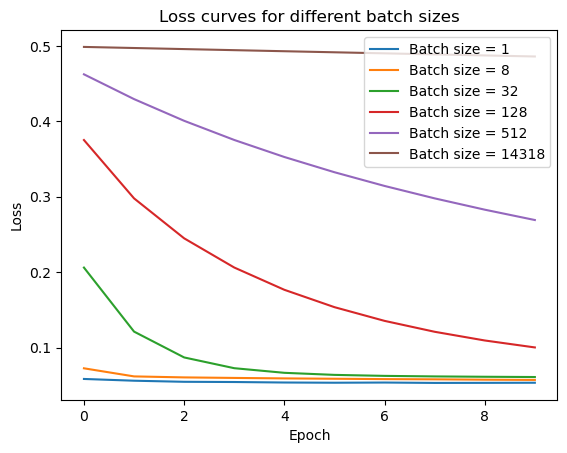

In [25]:
import matplotlib.pyplot as plt

for batch_size in batch_sizes:
    plt.plot(
        results_fixed_epochs[batch_size]["losses"],
        label=f"Batch size = {batch_size}"
    )
    
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves for different batch sizes")
plt.show()

In [26]:
## Fixed batch size and varying number of epochs (wrong exercise)

batch_size = 32
num_epochs_list = [1, 5, 10, 50, 100]

results_fixed_batch_size = {}

for num_epochs in num_epochs_list:
    model = SGDClassifier(
        w=np.zeros(X_train.shape[1]),
        b=0.0
    )
    
    w, b, losses, accuracies = model.fit(
        X_train,
        Y_train,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size
    )
    
    results_fixed_batch_size[num_epochs] = {
        "losses": losses,
        "accuracies": accuracies
    }

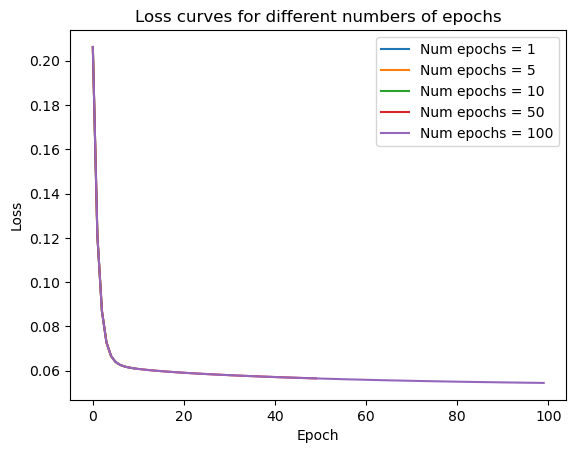

In [27]:
for num_epochs in num_epochs_list:
    plt.plot(
        results_fixed_batch_size[num_epochs]["losses"],
        label=f"Num epochs = {num_epochs}"
    )
    
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves for different numbers of epochs")
plt.show()

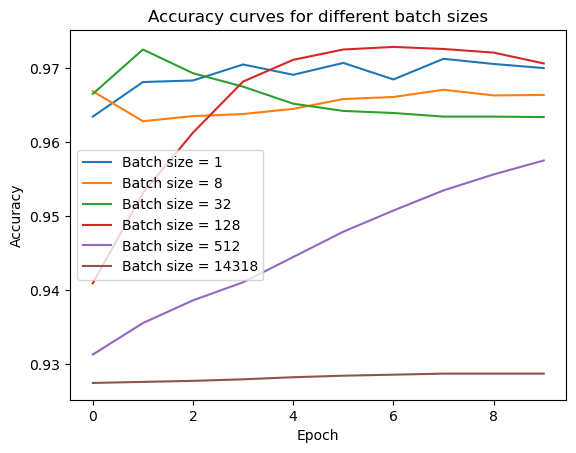

In [28]:
for batch_size in batch_sizes:
    plt.plot(
        results_fixed_epochs[batch_size]["accuracies"],
        label=f"Batch size = {batch_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy curves for different batch sizes")
plt.show()

In [29]:
# Fixed number of updates and varying batch sizes

updates = 1000
batch_sizes = [1, 8, 32, 128, 512, len(X_train)]
n_smples = X_train.shape[0]

results_fixed_updates = {}

for batch_size in batch_sizes:
    updates_per_epoch = int(np.ceil(X_train.shape[0] / batch_size))
    num_epochs = int(np.ceil(updates / updates_per_epoch))
    
    print(batch_size, updates_per_epoch, num_epochs)

model = SGDClassifier(
        w=np.zeros(X_train.shape[1]),
        b=0.0
    )
    
w, b, losses, accuracies = model.fit(
        X_train,
        Y_train,
        lr=lr,
        num_epochs = num_epochs,
        batch_size = batch_size
    )
    
results_fixed_updates[batch_size] = {
        "losses": losses,
        "accuracies": accuracies,
        "num_epochs": num_epochs,
        "updates_per_epoch": updates_per_epoch
    }

1 14318 1
8 1790 1
32 448 3
128 112 9
512 28 36
14318 1 1000


missing result for batch size: 1
missing result for batch size: 8
missing result for batch size: 32
missing result for batch size: 128
missing result for batch size: 512


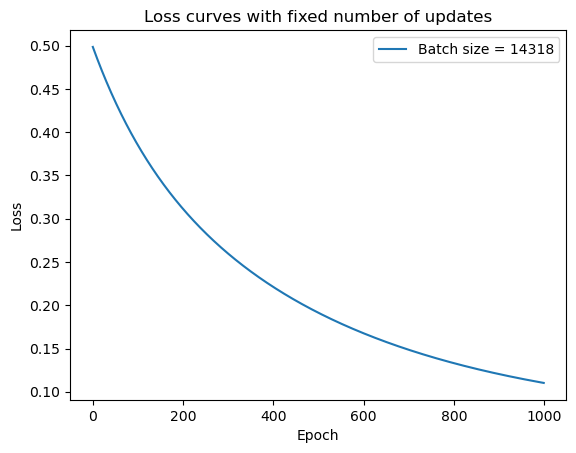

In [35]:
for batch_size in batch_sizes:
    if batch_size not in results_fixed_updates:
        print("missing result for batch size:", batch_size)
        continue
    
    plt.plot(
        results_fixed_updates[batch_size]["losses"],
        label=f"Batch size = {batch_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves with fixed number of updates")
plt.show()



In [36]:
print(results_fixed_updates.keys())

dict_keys([14318])


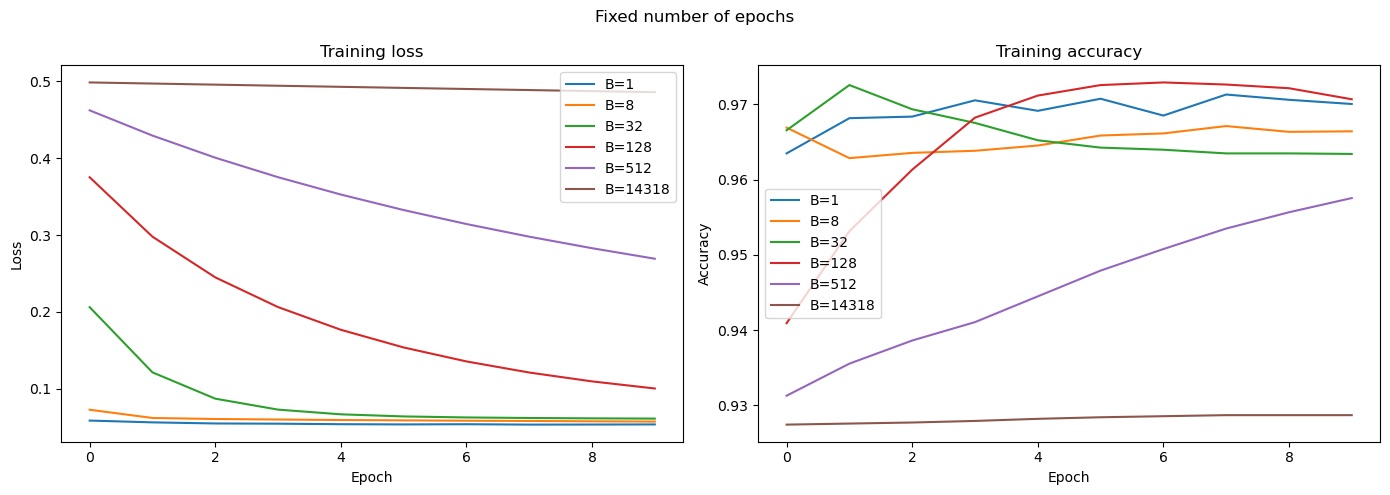

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for batch_size in batch_sizes:
    axes[0].plot(
        results_fixed_epochs[batch_size]["losses"],
        label=f"B={batch_size}"
    )
    axes[1].plot(
        results_fixed_epochs[batch_size]["accuracies"],
        label=f"B={batch_size}"
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training accuracy")

axes[0].legend()
axes[1].legend()

fig.suptitle("Fixed number of epochs")
plt.tight_layout()
plt.show()

In [40]:
print(batch_sizes)
print(results_fixed_updates.keys())

[1, 8, 32, 128, 512, 14318]
dict_keys([14318])


missing result for batch size: 1
missing result for batch size: 8
missing result for batch size: 32
missing result for batch size: 128
missing result for batch size: 512


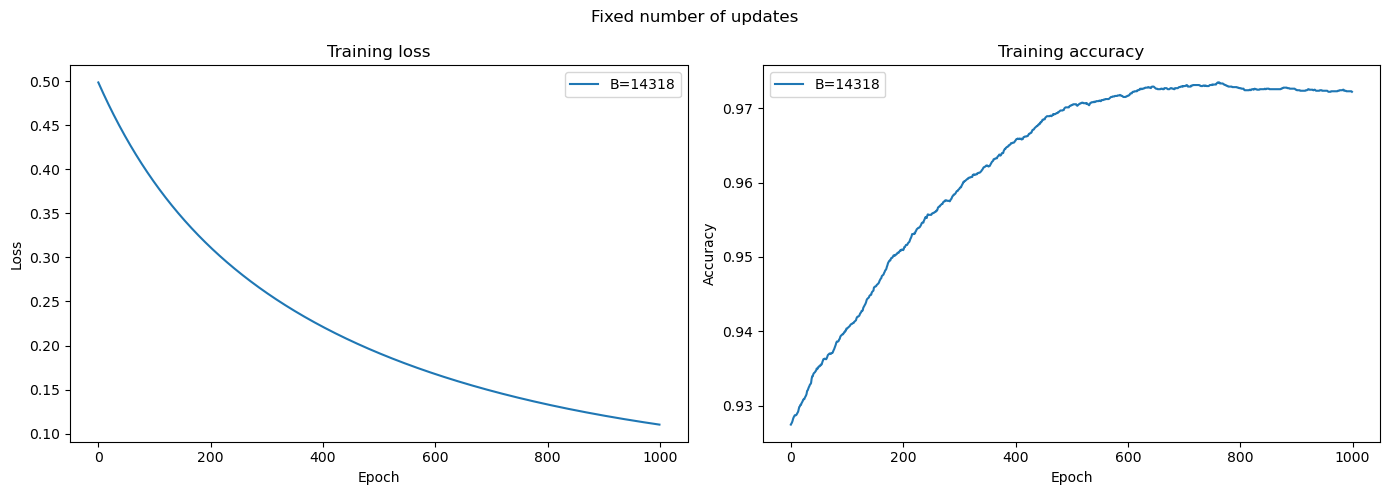

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for batch_size in batch_sizes:
    if batch_size not in results_fixed_updates:
        print("missing result for batch size:", batch_size)
        continue
    
    axes[0].plot(
        results_fixed_updates[batch_size]["losses"],
        label=f"B={batch_size}"
    )
    axes[1].plot(
        results_fixed_updates[batch_size]["accuracies"],
        label=f"B={batch_size}"
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training accuracy")

axes[0].legend()
axes[1].legend()

fig.suptitle("Fixed number of updates")
plt.tight_layout()
plt.show()

In [ ]:
## timing the model training
# first for the fixed number of epochs and varying batch sizes

import time

times_fixed_epochs = {}

for batch_size in batch_sizes:
    model = SGDClassifier(
        w=np.zeros(X_train.shape[1]),
        b=0.0
    )

    start = time.time()

    w, b, losses, accuracies = model.fit(
        X_train,
        Y_train,
        lr=lr,
        num_epochs=10,
        batch_size=batch_size
    )

    end = time.time()

    times_fixed_epochs[batch_size] = end - start

times_fixed_epochs

{1: 2.068634510040283,
 8: 0.2673952579498291,
 32: 0.07386469841003418,
 128: 0.024116039276123047,
 512: 0.01645946502685547,
 14318: 0.007596492767333984}

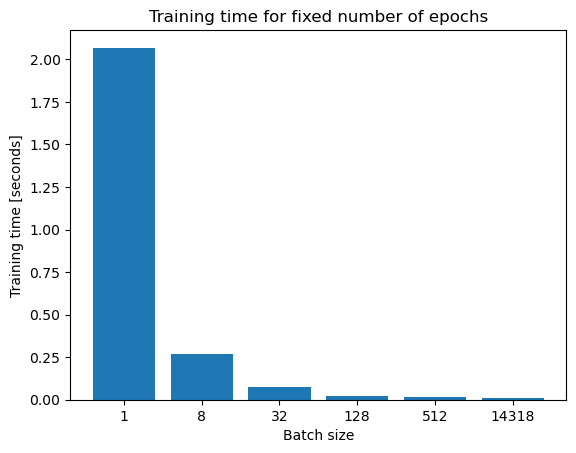

In [43]:
plt.bar(
    [str(b) for b in times_fixed_epochs.keys()],
    times_fixed_epochs.values()
)

plt.xlabel("Batch size")
plt.ylabel("Training time [seconds]")
plt.title("Training time for fixed number of epochs")
plt.show()

In [44]:
# timing the model training for fixed number of updates and varying batch sizes

times_fixed_updates = {}

for batch_size in batch_sizes:
    updates_per_epoch = int(np.ceil(len(X_train) / batch_size))
    num_epochs = int(np.ceil(updates / updates_per_epoch))

    model = SGDClassifier(
        w=np.zeros(X_train.shape[1]),
        b=0.0
    )

    start = time.time()

    w, b, losses, accuracies = model.fit(
        X_train,
        Y_train,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size
    )

    end = time.time()

    times_fixed_updates[batch_size] = end - start

times_fixed_updates

{1: 0.16483044624328613,
 8: 0.02363109588623047,
 32: 0.020206689834594727,
 128: 0.024908065795898438,
 512: 0.05539679527282715,
 14318: 0.8162024021148682}

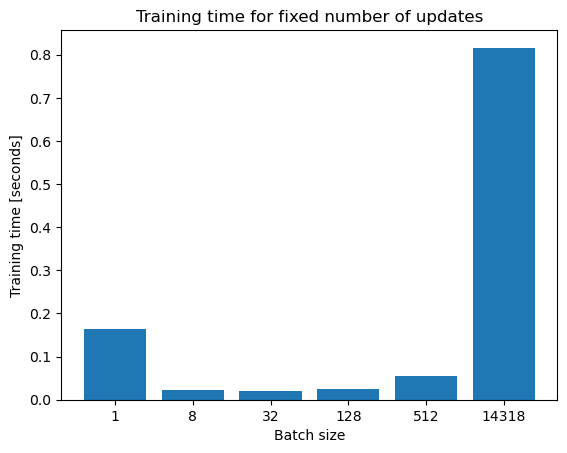

In [45]:
plt.bar(
    [str(b) for b in times_fixed_updates.keys()],
    times_fixed_updates.values()
)

plt.xlabel("Batch size")
plt.ylabel("Training time [seconds]")
plt.title("Training time for fixed number of updates")
plt.show()

### Discussion

The Mini-batch SGD classifier was trained using different batch sizes and evaluated under two settings: a fixed number of epochs and a fixed number of updates.

For the **fixed number of epochs** experiment, smaller batch sizes generally achieved lower losses and higher accuracies because they performed many more parameter updates per epoch. Batch sizes 1 and 128 showed particularly good convergence behavior. However, small batch sizes required significantly more computation time. Batch size 1 took approximately 2.06 seconds, while full-batch gradient descent required only about 0.007 seconds.

For the **fixed number of updates** experiment, the comparison became fairer because all models performed approximately the same number of parameter updates. The differences in convergence performance became smaller. Training times for most batch sizes were between 0.02 and 0.05 seconds. Batch size 1 required about 0.16 seconds, while full-batch gradient descent (batch size 14318) required about 0.81 seconds because each update involved processing the entire training set.

Overall, small batch sizes often achieved faster convergence but required more computation. Large batch sizes produced smoother learning curves and more stable updates but could be computationally expensive when the entire dataset was processed in each update. Medium-sized batches provided a good compromise between convergence speed, stability, and computational efficiency.
